# **EN3160 – Computer Vision**
## **Assignment 01: Intensity Transformations and Neighborhood Filtering**

**Name:** Saruka U.  
**Index Number:** 230585C  

---

# Question 1 – Intensity Transformation

In [10]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

breakpoints = np.array([
    [0, 0],
    [50, 50],
    [100, 150],
    [150, 255],
    [255, 255]
])

def intensity_transform(im, breakpoints):
    # Make sure the breakpoints are sorted by input intensity
    breakpoints = np.asarray(breakpoints, dtype=np.float32)
    breakpoints = breakpoints[np.argsort(breakpoints[:, 0])]

    # Create output image with floating-point values
    output = np.zeros_like(im, dtype=np.float32)

    # Process each interval between consecutive breakpoints
    for i in range(len(breakpoints) - 1):

        x1, y1 = breakpoints[i]
        x2, y2 = breakpoints[i + 1]

        # Pixels belonging to this intensity interval
        mask = (im >= x1) & (im <= x2)

        # Piecewise linear interpolation
        output[mask] = (
            y1 + (y2 - y1) / (x2 - x1) * (im[mask] - x1)
        )

    # Handle values below the first breakpoint
    output[im < breakpoints[0, 0]] = breakpoints[0, 1]

    # Handle values above the last breakpoint
    output[im > breakpoints[-1, 0]] = breakpoints[-1, 1]

    # Convert back to 8-bit image
    output = np.clip(output, 0, 255).astype(np.uint8)

    return output


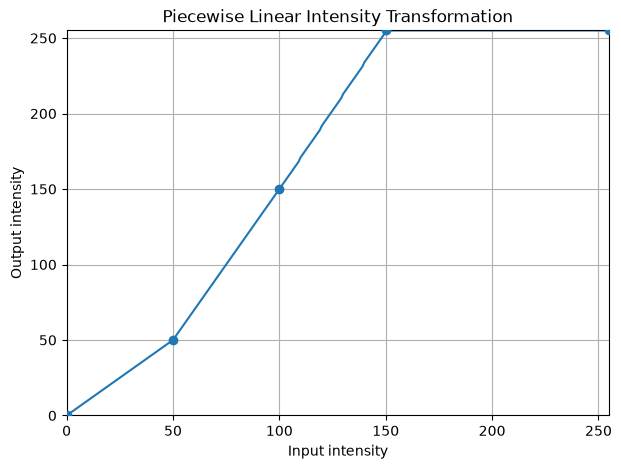

In [7]:
x = np.arange(256, dtype=np.uint8)

# Treat the intensity values as a 1 × 256 image
x_image = x.reshape(1, -1)

# Apply the transformation
y = intensity_transform(x_image, breakpoints)[0]

plt.figure(figsize=(7, 5))

plt.plot(x, y)

# Show the specified breakpoints
plt.scatter(
    breakpoints[:, 0],
    breakpoints[:, 1],
    zorder=3
)

plt.xlabel("Input intensity")
plt.ylabel("Output intensity")
plt.title("Piecewise Linear Intensity Transformation")
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.grid(True)

plt.show()

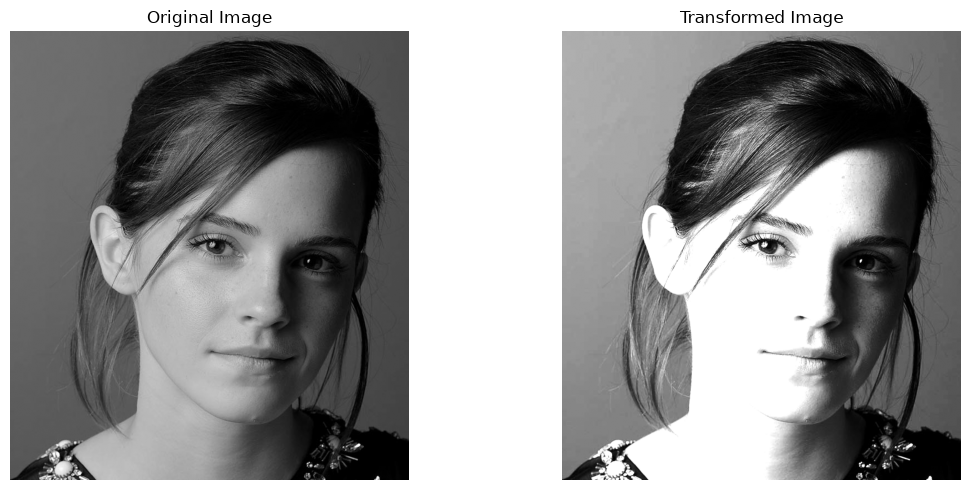

In [9]:
im = cv.imread("images/q1/fig1.jpg", cv.IMREAD_GRAYSCALE)

transformed = intensity_transform(im, breakpoints)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].imshow(im, cmap="gray", vmin=0, vmax=255)
ax[0].set_title("Original Image")
ax[0].axis("off")

ax[1].imshow(transformed, cmap="gray", vmin=0, vmax=255)
ax[1].set_title("Transformed Image")
ax[1].axis("off")

plt.tight_layout()
plt.show()

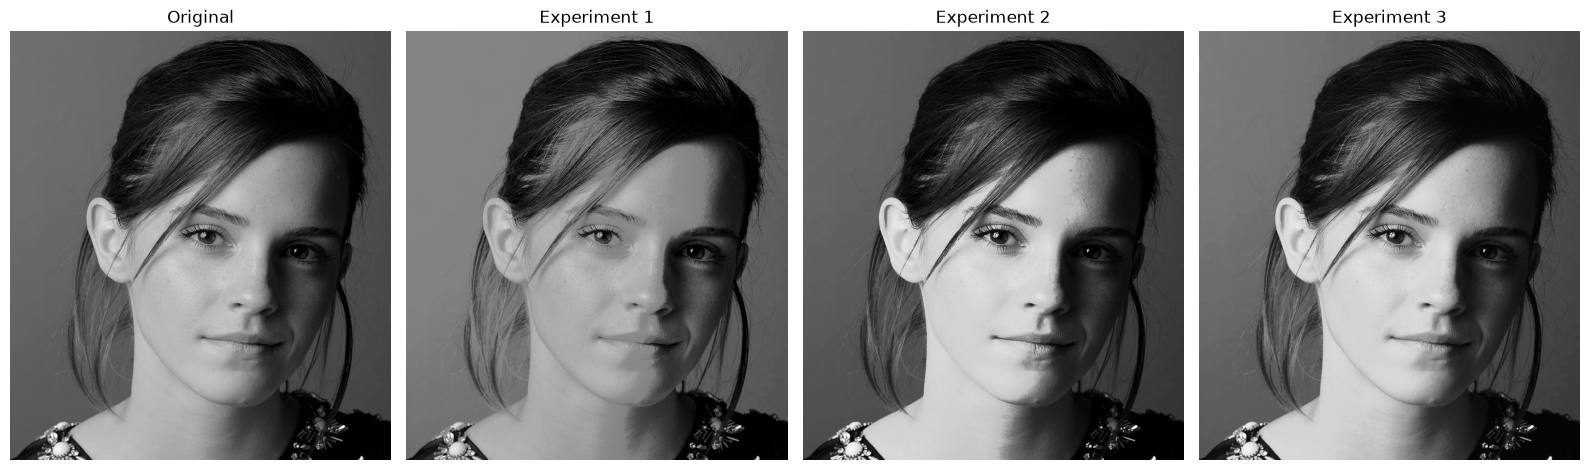

In [15]:
breakpoints_1 = np.array([
    [0, 0],
    [50, 60],
    [100, 130],
    [150, 140],
    [255, 240]
])

breakpoints_2 = np.array([
    [0, 0],
    [60, 45],
    [120, 115],
    [150, 190],
    [255, 255]
])

breakpoints_3 = np.array([
    [0, 5],
    [60, 50],
    [120, 135],
    [180, 210],
    [255, 250]
])

transformed_1 = intensity_transform(im, breakpoints_1)
transformed_2 = intensity_transform(im, breakpoints_2)
transformed_3 = intensity_transform(im, breakpoints_3)

fig, ax = plt.subplots(1, 4, figsize=(16, 5))

ax[0].imshow(im, cmap="gray", vmin=0, vmax=255)
ax[0].set_title("Original")
ax[0].axis("off")

ax[1].imshow(transformed_1, cmap="gray", vmin=0, vmax=255)
ax[1].set_title("Experiment 1")
ax[1].axis("off")

ax[2].imshow(transformed_2, cmap="gray", vmin=0, vmax=255)
ax[2].set_title("Experiment 2")
ax[2].axis("off")

ax[3].imshow(transformed_3, cmap="gray", vmin=0, vmax=255)
ax[3].set_title("Experiment 3")
ax[3].axis("off")

plt.tight_layout()
plt.show()

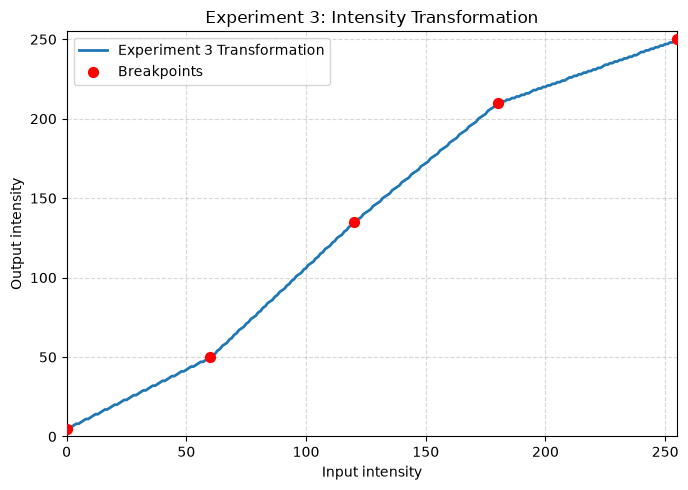

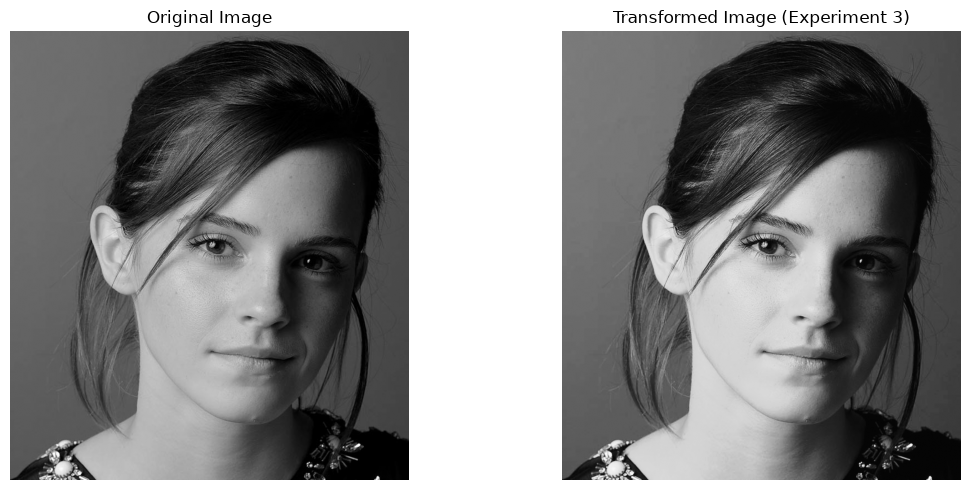

In [17]:
x = np.arange(256, dtype=np.uint8)
x_image = x.reshape(1, -1)

# Apply the transformation to all intensity values
y = intensity_transform(x_image, breakpoints_3)[0]

plt.figure(figsize=(7, 5))

plt.plot(x, y, linewidth=2, label="Experiment 3 Transformation")
plt.scatter(
    breakpoints_3[:, 0],
    breakpoints_3[:, 1],
    color="red",
    s=50,
    zorder=3,
    label="Breakpoints"
)

plt.title("Experiment 3: Intensity Transformation")
plt.xlabel("Input intensity")
plt.ylabel("Output intensity")

plt.xlim(0, 255)
plt.ylim(0, 255)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()


fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].imshow(im, cmap="gray", vmin=0, vmax=255)
ax[0].set_title("Original Image")
ax[0].axis("off")

ax[1].imshow(transformed_3, cmap="gray", vmin=0, vmax=255)
ax[1].set_title("Transformed Image (Experiment 3)")
ax[1].axis("off")

plt.tight_layout()
plt.show()

### **Selection of the Best Transformation**

Three different sets of breakpoints were tested to obtain a visually pleasing intensity transformation. Experiment 1 provides a relatively mild enhancement, while Experiment 2 produces stronger contrast and brightness but causes some bright regions of the face to become over-enhanced. Experiment 3 provides a better balance between contrast enhancement and preservation of image details. Therefore, Experiment 3 was selected as the most visually pleasing transformation.

# Question 2 — Intensity Transformation for Brain Tissue

Image shape: (588, 495)
Image dtype: uint8


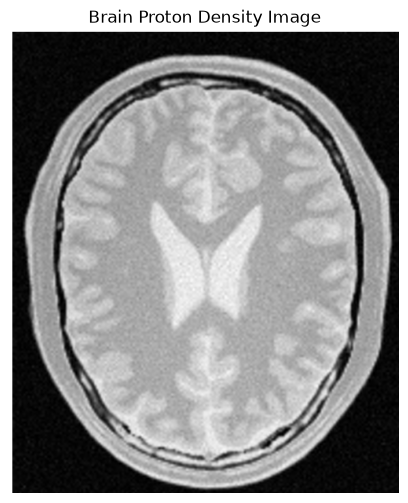

In [18]:
# Load the brain proton density image

brain = cv.imread("images/q2/fig2.png", cv.IMREAD_GRAYSCALE)

print("Image shape:", brain.shape)
print("Image dtype:", brain.dtype)

plt.figure(figsize=(6, 6))
plt.imshow(brain, cmap="gray", vmin=0, vmax=255)
plt.title("Brain Proton Density Image")
plt.axis("off")
plt.show()

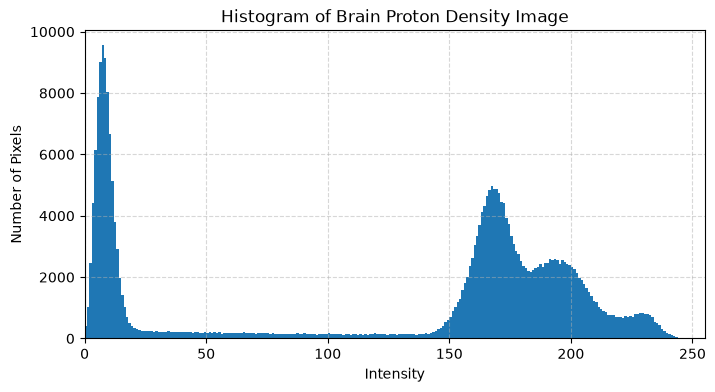

In [19]:
plt.figure(figsize=(8, 4))

plt.hist(brain.ravel(), bins=256, range=(0, 256))

plt.title("Histogram of Brain Proton Density Image")
plt.xlabel("Intensity")
plt.ylabel("Number of Pixels")

plt.xlim(0, 255)
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

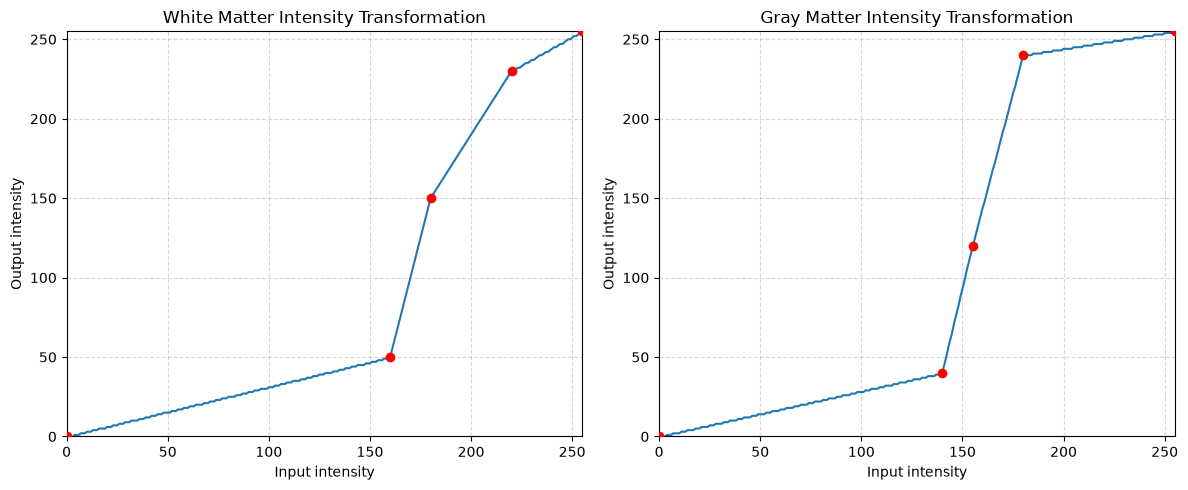

In [28]:
breakpoints_wm = np.array([
    [0, 0],
    [160, 50],
    [180, 150],
    [220, 230],
    [255, 255]
])

breakpoints_gm = np.array([
    [0, 0],
    [140, 40],
    [155, 120],
    [180, 240],
    [255, 255]
])

# Create intensity values from 0 to 255
x = np.arange(256, dtype=np.uint8)
x_image = x.reshape(1, -1)

# Calculate transformation curves
y_wm = intensity_transform(x_image, breakpoints_wm)[0]
y_gm = intensity_transform(x_image, breakpoints_gm)[0]


# Plot transformations
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].plot(x, y_wm)
ax[0].scatter(
    breakpoints_wm[:, 0],
    breakpoints_wm[:, 1],
    color="red",
    zorder=3
)
ax[0].set_title("White Matter Intensity Transformation")
ax[0].set_xlabel("Input intensity")
ax[0].set_ylabel("Output intensity")
ax[0].set_xlim(0, 255)
ax[0].set_ylim(0, 255)
ax[0].grid(True, linestyle="--", alpha=0.5)

ax[1].plot(x, y_gm)
ax[1].scatter(
    breakpoints_gm[:, 0],
    breakpoints_gm[:, 1],
    color="red",
    zorder=3
)
ax[1].set_title("Gray Matter Intensity Transformation")
ax[1].set_xlabel("Input intensity")
ax[1].set_ylabel("Output intensity")
ax[1].set_xlim(0, 255)
ax[1].set_ylim(0, 255)
ax[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

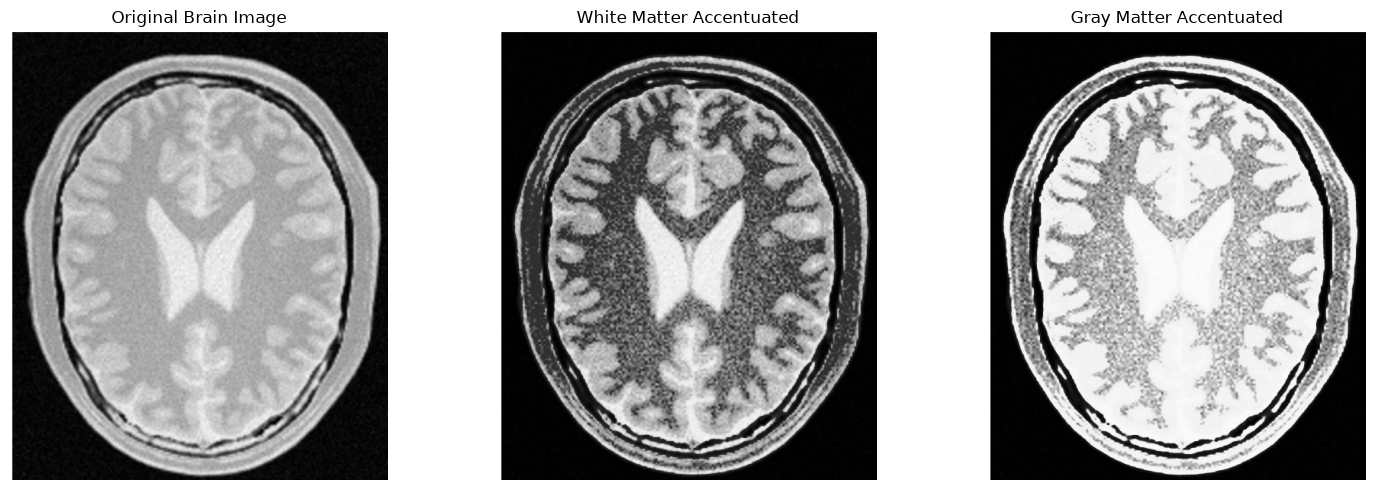

In [29]:
# Apply the transformations
brain_wm = intensity_transform(brain, breakpoints_wm)
brain_gm = intensity_transform(brain, breakpoints_gm)


# Display results
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(brain, cmap="gray", vmin=0, vmax=255)
ax[0].set_title("Original Brain Image")
ax[0].axis("off")

ax[1].imshow(brain_wm, cmap="gray", vmin=0, vmax=255)
ax[1].set_title("White Matter Accentuated")
ax[1].axis("off")

ax[2].imshow(brain_gm, cmap="gray", vmin=0, vmax=255)
ax[2].set_title("Gray Matter Accentuated")
ax[2].axis("off")

plt.tight_layout()
plt.show()

### **Breakpoint Selection**

The breakpoint values were selected experimentally based on the intensity distribution of the brain proton-density image. The transformations were adjusted to increase the contrast of the intensity regions associated with the target tissue while keeping the background relatively dark. The final breakpoint sets were selected based on the visual separation and visibility of the respective tissue regions.